In [1]:
# === CELL 1: Import thư viện và đọc dữ liệu ===

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

# Đọc file CSV
df = pd.read_csv('Evasive-PDF-Samples.csv')

# Xem thông tin tổng quan
print("=" * 50)
print("THÔNG TIN TỔNG QUAN DATASET")
print("=" * 50)
print(f"Số mẫu (rows): {df.shape[0]:,}")
print(f"Số cột (columns): {df.shape[1]}")
print(f"\nDanh sách cột:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:2d}. {col}")
print(f"\nKiểu dữ liệu:")
print(df.dtypes)
print(f"\n5 dòng đầu tiên:")
df.head()

THÔNG TIN TỔNG QUAN DATASET
Số mẫu (rows): 500,000
Số cột (columns): 21

Danh sách cột:
   1. pdfsize
   2. pages
   3. title characters
   4. images
   5. obj
   6. endobj
   7. stream
   8. endstream
   9. xref
  10. trailer
  11. startxref
  12. ObjStm
  13. JS
  14. OBS_JS
  15. Javascript
  16. OBS_Javascript
  17. OpenAction
  18. OBS_OpenAction
  19. Acroform
  20. OBS_Acroform
  21. class

Kiểu dữ liệu:
pdfsize             float64
pages                 int64
title characters      int64
images                int64
obj                   int64
endobj                int64
stream                int64
endstream             int64
xref                  int64
trailer               int64
startxref             int64
ObjStm                int64
JS                    int64
OBS_JS                int64
Javascript            int64
OBS_Javascript        int64
OpenAction            int64
OBS_OpenAction        int64
Acroform              int64
OBS_Acroform          int64
class                 int

,pdfsize,pages,title characters,images,obj,endobj,stream,endstream,xref,trailer,...,ObjStm,JS,OBS_JS,Javascript,OBS_Javascript,OpenAction,OBS_OpenAction,Acroform,OBS_Acroform,class
0,644.326,70,0,1,348,351,128,128,1,1,...,0,1,0,1,0,1,0,1,0,1
1,648.050,68,0,1,348,345,124,124,1,1,...,0,1,0,1,0,0,0,1,0,1
2,696.506,68,0,1,353,353,128,125,1,1,...,0,1,0,1,0,0,0,1,0,1
3,715.926,68,0,0,759,667,250,192,1,1,...,0,1,0,1,0,1,0,1,0,1
4,707.102,70,10,2,388,373,141,138,1,1,...,0,1,0,1,0,1,0,1,0,1


In [2]:
# === CELL 2: Thống kê mô tả ===

print("=" * 50)
print("THỐNG KÊ MÔ TẢ (DESCRIBE)")
print("=" * 50)
print(df.describe().T.to_string())

print(f"\n{'=' * 50}")
print("KIỂM TRA MISSING VALUES")
print("=" * 50)
missing = df.isnull().sum()
print(f"Tổng missing values: {missing.sum()}")
if missing.sum() == 0:
    print("→ Dataset KHÔNG có giá trị thiếu!")

print(f"\n{'=' * 50}")
print("KIỂM TRA DUPLICATES")
print("=" * 50)
dup_count = df.duplicated().sum()
print(f"Số dòng trùng lặp: {dup_count:,}")
print(f"Tỷ lệ: {dup_count/len(df)*100:.2f}%")

THỐNG KÊ MÔ TẢ (DESCRIBE)
                     count        mean         std  min        25%      50%        75%       max
pdfsize           500000.0  563.363772  280.213763  0.0  585.86425  657.841  708.50325  1761.042
pages             500000.0   55.101686   30.233062  0.0   67.00000   68.000   69.00000   287.000
title characters  500000.0    5.617004    6.501397  0.0    0.00000    4.000    9.00000   267.000
images            500000.0    1.041594    0.734654  0.0    1.00000    1.000    2.00000    18.000
obj               500000.0  273.595072  142.333280  0.0  266.00000  346.000  355.00000   760.000
endobj            500000.0  273.472290  142.734185  0.0  266.00000  345.000  354.00000   760.000
stream            500000.0   95.115512   51.683914  0.0   85.00000  123.000  126.00000   254.000
endstream         500000.0   95.331500   52.094421  0.0   87.00000  122.000  126.00000   254.000
xref              500000.0    0.969714    0.263349  0.0    1.00000    1.000    1.00000     3.000
trai

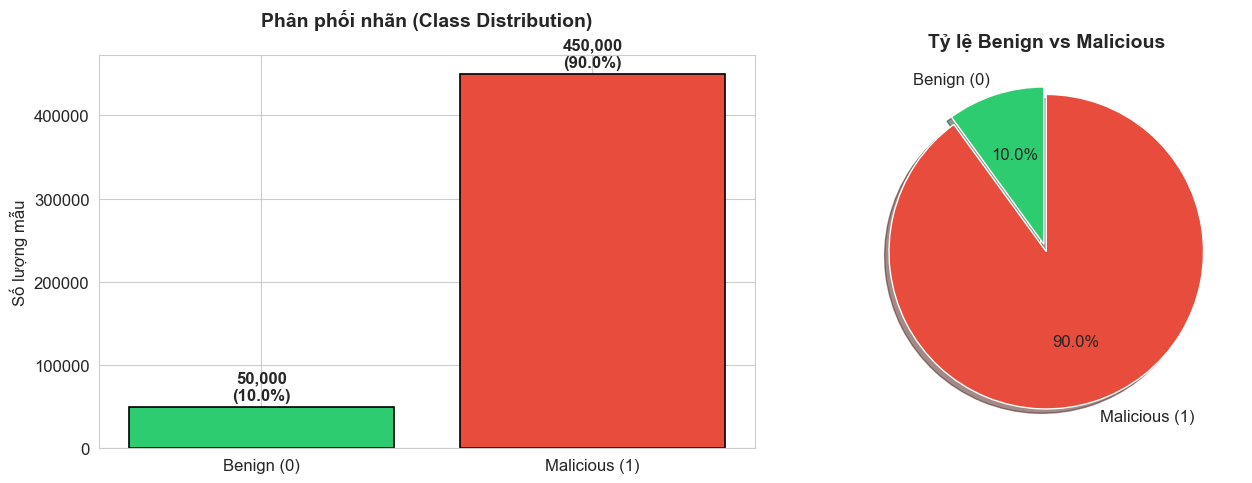


→ Dataset mất cân bằng nghiêm trọng: Malicious chiếm 90%, Benign chỉ 10%
→ Tỷ lệ Malicious:Benign = 9:1


In [33]:
# === CELL 3: Phân phối nhãn ===

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Biểu đồ cột
class_counts = df['class'].value_counts()
colors = ['#2ecc71', '#e74c3c']
bars = axes[0].bar(['Benign (0)', 'Malicious (1)'],
                    [class_counts[0], class_counts[1]],
                    color=colors, edgecolor='black', linewidth=1.2)
axes[0].set_title('Phân phối nhãn (Class Distribution)\n', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Số lượng mẫu', fontsize=12)
# Thêm số liệu lên đầu cột
for bar, count in zip(bars, [class_counts[0], class_counts[1]]):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 5000,
                f'{count:,}\n({count/len(df)*100:.1f}%)',
                ha='center', va='bottom', fontsize=12, fontweight='bold')

# Biểu đồ tròn
axes[1].pie([class_counts[0], class_counts[1]],
            labels=['Benign (0)', 'Malicious (1)'],
            colors=colors, autopct='%1.1f%%', startangle=90,
            textprops={'fontsize': 12}, explode=(0.05, 0),
            shadow=True)
axes[1].set_title('Tỷ lệ Benign vs Malicious', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n→ Dataset mất cân bằng nghiêm trọng: Malicious chiếm 90%, Benign chỉ 10%")
print(f"→ Tỷ lệ Malicious:Benign = {class_counts[1]//class_counts[0]}:1")

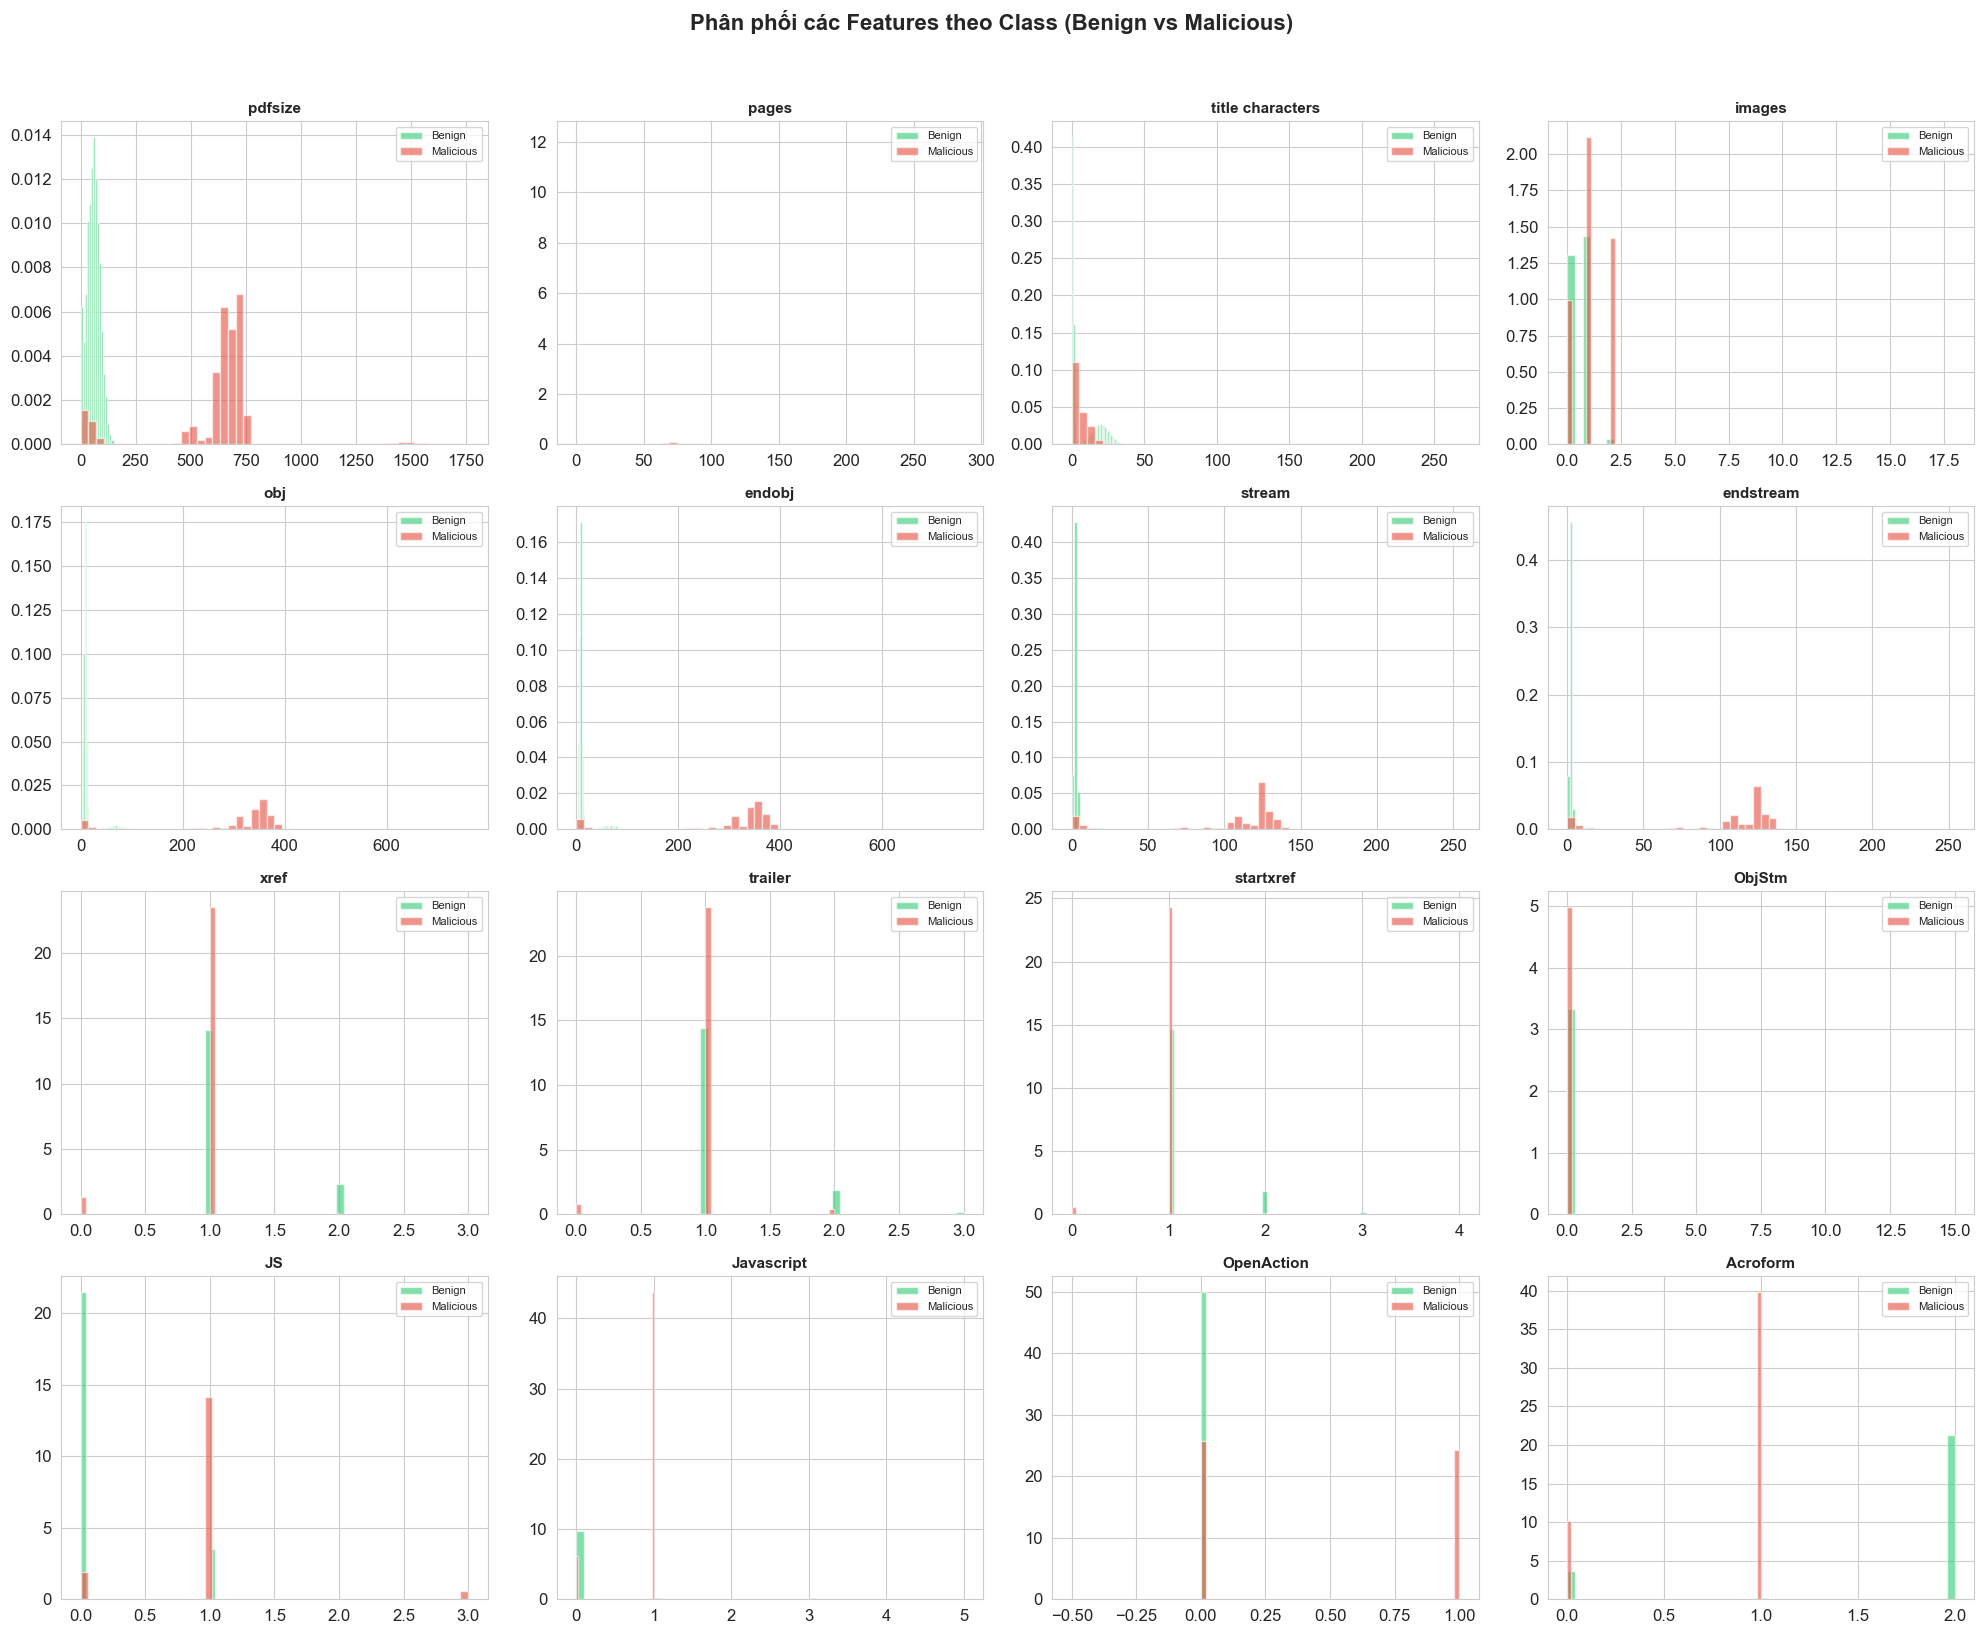

→ Các features có phân phối KHÁC BIỆT rõ giữa 2 class sẽ là features quan trọng cho mô hình
→ Các features có phân phối GIỐNG NHAU giữa 2 class sẽ ít có giá trị phân loại


In [4]:
# === CELL 4: Histogram phân phối các features ===

# Loại bỏ cột class và 4 cột OBS_ có giá trị = 0 để biểu đồ có ý nghĩa
zero_cols = ['OBS_JS', 'OBS_Javascript', 'OBS_OpenAction', 'OBS_Acroform']
feature_cols = [col for col in df.columns if col != 'class' and col not in zero_cols]

fig, axes = plt.subplots(4, 4, figsize=(20, 16))
axes = axes.flatten()

for i, col in enumerate(feature_cols):
    axes[i].hist(df[df['class']==0][col], bins=50, alpha=0.6, color='#2ecc71', label='Benign', density=True)
    axes[i].hist(df[df['class']==1][col], bins=50, alpha=0.6, color='#e74c3c', label='Malicious', density=True)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].legend(fontsize=8)

# Ẩn các ô thừa (nếu có)
for j in range(len(feature_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Phân phối các Features theo Class (Benign vs Malicious)',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("→ Các features có phân phối KHÁC BIỆT rõ giữa 2 class sẽ là features quan trọng cho mô hình")
print("→ Các features có phân phối GIỐNG NHAU giữa 2 class sẽ ít có giá trị phân loại")

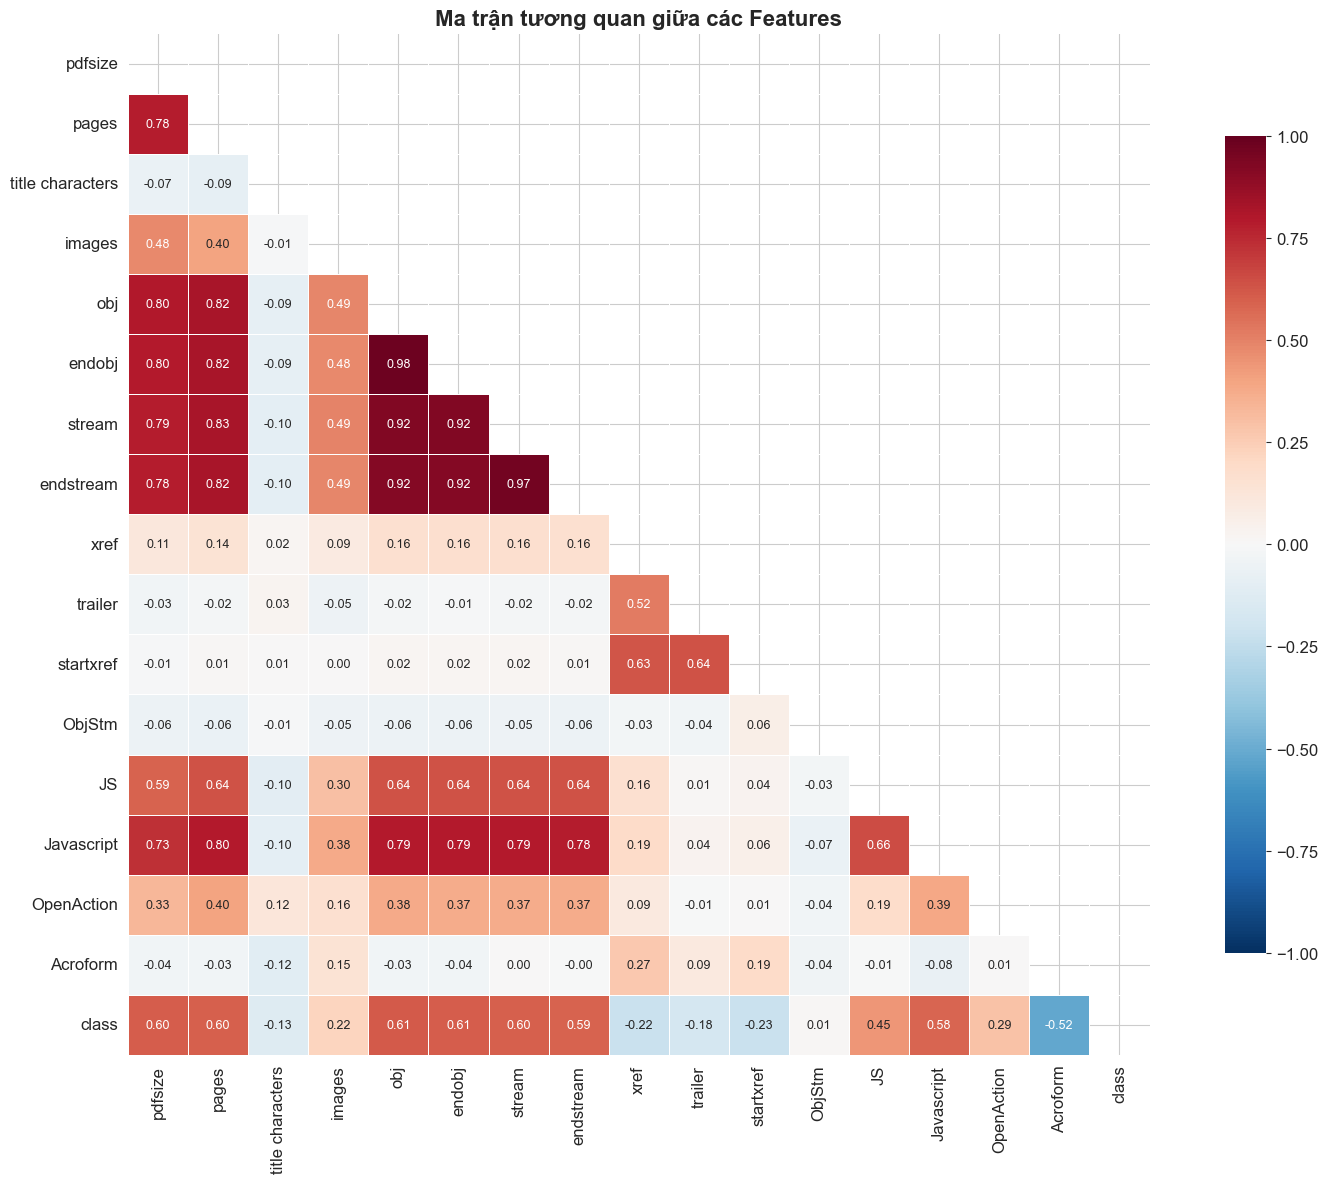


→ CÁC CẶP FEATURES CÓ TƯƠNG QUAN CAO (|r| > 0.8):
   • pdfsize & obj: r = 0.801
   • pages & obj: r = 0.822
   • pages & endobj: r = 0.821
   • pages & stream: r = 0.826
   • pages & endstream: r = 0.823
   • obj & endobj: r = 0.977
   • obj & stream: r = 0.922
   • obj & endstream: r = 0.920
   • endobj & stream: r = 0.923
   • endobj & endstream: r = 0.922
   • stream & endstream: r = 0.968


In [5]:
# === CELL 5: Ma trận tương quan ===

# Loại bỏ 4 cột OBS_ có giá trị = 0
zero_cols = ['OBS_JS', 'OBS_Javascript', 'OBS_OpenAction', 'OBS_Acroform']
df_corr = df.drop(columns=zero_cols)

fig, ax = plt.subplots(figsize=(16, 12))

corr_matrix = df_corr.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Chỉ hiện nửa dưới

sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            square=True, linewidths=0.5,
            annot_kws={'size': 9},
            cbar_kws={'shrink': 0.8})

plt.title('Ma trận tương quan giữa các Features', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

# In ra các cặp features tương quan cao
print("\n→ CÁC CẶP FEATURES CÓ TƯƠNG QUAN CAO (|r| > 0.8):")
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.8:
            print(f"   • {corr_matrix.columns[i]} & {corr_matrix.columns[j]}: r = {r:.3f}")

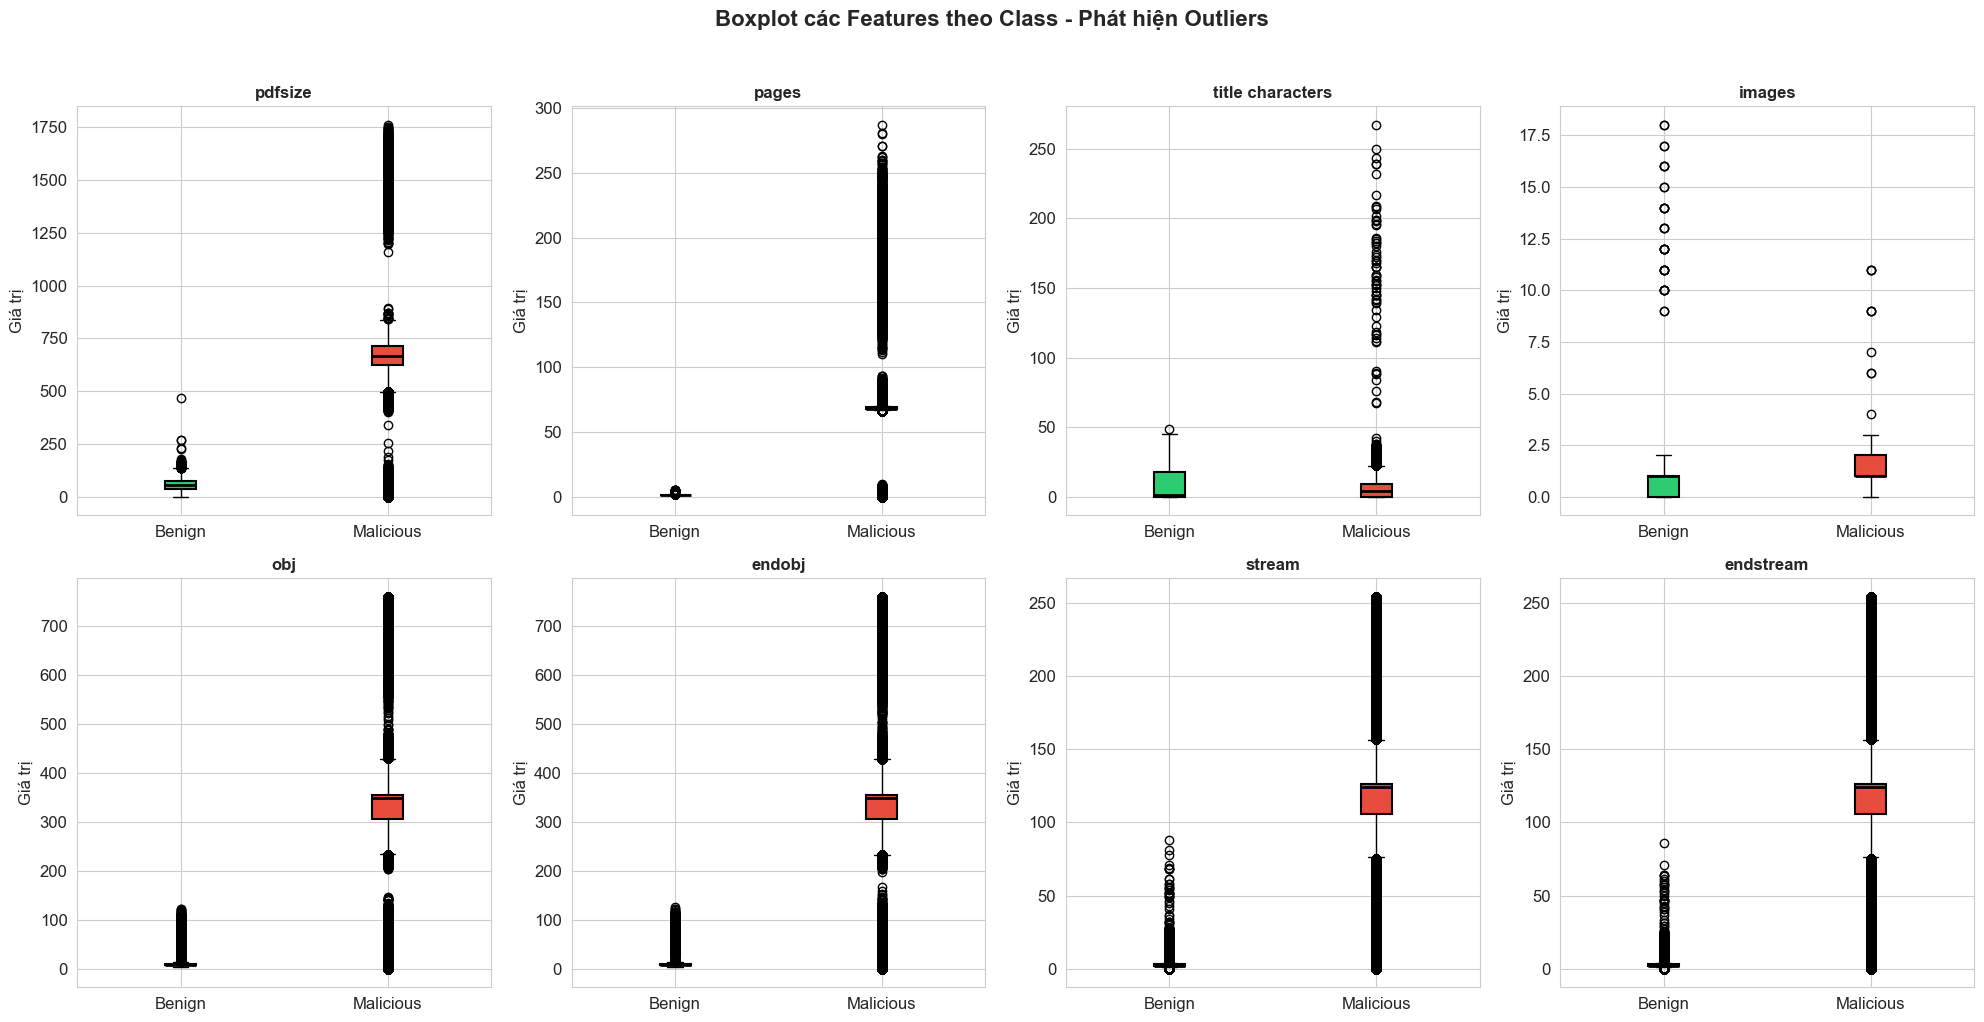

→ Các điểm nằm ngoài râu (whiskers) là Outliers
→ So sánh median (đường đen) giữa 2 class để thấy sự khác biệt


In [6]:
# === CELL 6: Boxplot phát hiện Outliers ===

# Chỉ vẽ cho các features có dải giá trị rộng (features số lượng lớn)
continuous_features = ['pdfsize', 'pages', 'title characters', 'images',
                       'obj', 'endobj', 'stream', 'endstream']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(continuous_features):
    data_benign = df[df['class']==0][col]
    data_malicious = df[df['class']==1][col]

    bp = axes[i].boxplot([data_benign, data_malicious],
                          labels=['Benign', 'Malicious'],
                          patch_artist=True,
                          boxprops=dict(linewidth=1.5),
                          medianprops=dict(color='black', linewidth=2))

    bp['boxes'][0].set_facecolor('#2ecc71')
    bp['boxes'][1].set_facecolor('#e74c3c')

    axes[i].set_title(col, fontsize=12, fontweight='bold')
    axes[i].set_ylabel('Giá trị')

plt.suptitle('Boxplot các Features theo Class - Phát hiện Outliers',
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("→ Các điểm nằm ngoài râu (whiskers) là Outliers")
print("→ So sánh median (đường đen) giữa 2 class để thấy sự khác biệt")

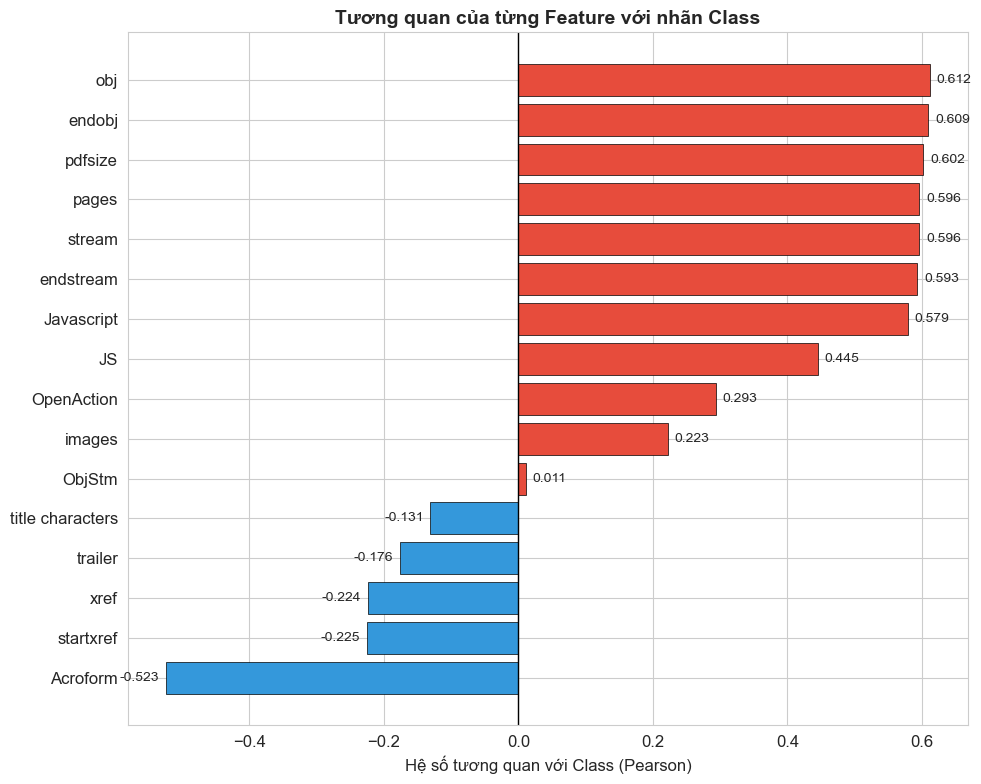


→ Đỏ = tương quan DƯƠNG (feature tăng → xu hướng Malicious)
→ Xanh = tương quan ÂM (feature tăng → xu hướng Benign)
→ Giá trị càng xa 0 → feature càng quan trọng cho phân loại


In [7]:
# === CELL 7: Tương quan từng Feature với Class ===

zero_cols = ['OBS_JS', 'OBS_Javascript', 'OBS_OpenAction', 'OBS_Acroform']
feature_cols = [col for col in df.columns if col != 'class' and col not in zero_cols]

# Tính tương quan với cột class
corr_with_class = df[feature_cols].corrwith(df['class']).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))

colors = ['#e74c3c' if x > 0 else '#3498db' for x in corr_with_class.values]
bars = ax.barh(corr_with_class.index, corr_with_class.values, color=colors, edgecolor='black', linewidth=0.5)

ax.set_xlabel('Hệ số tương quan với Class (Pearson)', fontsize=12)
ax.set_title('Tương quan của từng Feature với nhãn Class', fontsize=14, fontweight='bold')
ax.axvline(x=0, color='black', linewidth=1)

# Thêm giá trị lên thanh
for bar, val in zip(bars, corr_with_class.values):
    ax.text(val + (0.01 if val > 0 else -0.01), bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', ha='left' if val > 0 else 'right', va='center', fontsize=10)

plt.tight_layout()
plt.show()

print("\n→ Đỏ = tương quan DƯƠNG (feature tăng → xu hướng Malicious)")
print("→ Xanh = tương quan ÂM (feature tăng → xu hướng Benign)")
print("→ Giá trị càng xa 0 → feature càng quan trọng cho phân loại")

In [8]:
# === CELL 8: Tiền xử lý hoàn chỉnh ===

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

# ============================================================
# BƯỚC 1: LOẠI BỎ CỘT KHÔNG CÓ GIÁ TRỊ
# ============================================================
print("=" * 60)
print("BƯỚC 1: LOẠI BỎ CỘT KHÔNG CÓ GIÁ TRỊ")
print("=" * 60)

zero_cols = ['OBS_JS', 'OBS_Javascript', 'OBS_OpenAction', 'OBS_Acroform']
df_clean = df.drop(columns=zero_cols)
print(f"Đã loại bỏ {len(zero_cols)} cột: {zero_cols}")
print(f"Số cột còn lại: {df_clean.shape[1]}")

# ============================================================
# BƯỚC 2: XỬ LÝ DÒNG TRÙNG LẶP
# ============================================================
print(f"\n{'=' * 60}")
print("BƯỚC 2: XỬ LÝ DÒNG TRÙNG LẶP")
print("=" * 60)

before = len(df_clean)
df_clean = df_clean.drop_duplicates()
after = len(df_clean)
print(f"Trước: {before:,} dòng → Sau: {after:,} dòng")
print(f"Đã loại bỏ: {before - after:,} dòng trùng lặp")

# ============================================================
# BƯỚC 3: XỬ LÝ ĐA CỘNG TUYẾN (MULTICOLLINEARITY)
# ============================================================
print(f"\n{'=' * 60}")
print("BƯỚC 3: XỬ LÝ ĐA CỘNG TUYẾN")
print("=" * 60)

# Từ Cell 5: các cặp có |r| > 0.9
# obj & endobj: r=0.977 → giữ obj (corr với class: 0.61) > endobj (0.61) → loại endobj
# obj & stream: r=0.922 → giữ obj (0.61) > stream (0.60) → loại stream
# obj & endstream: r=0.920 → giữ obj (0.61) > endstream (0.59) → loại endstream
# stream & endstream: r=0.968 → cả 2 đã bị loại ở trên
# endobj & stream: r=0.923 → cả 2 đã bị loại ở trên
# endobj & endstream: r=0.922 → cả 2 đã bị loại ở trên

drop_multicollinear = ['endobj', 'stream', 'endstream']

# Giải thích lý do giữ/loại
print("Các cặp features tương quan > 0.9:")
print("  • obj & endobj (r=0.977): GIỮ obj (corr class=0.61), LOẠI endobj")
print("  • obj & stream (r=0.922): GIỮ obj, LOẠI stream")
print("  • obj & endstream (r=0.920): GIỮ obj, LOẠI endstream")
print("  • stream & endstream (r=0.968): cả 2 đã loại ở trên")

df_clean = df_clean.drop(columns=drop_multicollinear)
print(f"\nĐã loại bỏ {len(drop_multicollinear)} cột: {drop_multicollinear}")
print(f"Số cột còn lại: {df_clean.shape[1]} ({df_clean.shape[1]-1} features + 1 label)")
print(f"Features còn lại: {[c for c in df_clean.columns if c != 'class']}")

# ============================================================
# BƯỚC 4: TÁCH FEATURES VÀ LABEL
# ============================================================
print(f"\n{'=' * 60}")
print("BƯỚC 4: TÁCH FEATURES VÀ LABEL")
print("=" * 60)

X = df_clean.drop(columns=['class'])
y = df_clean['class']
print(f"Features (X): {X.shape}")
print(f"Label (y): {y.shape}")

# ============================================================
# BƯỚC 5: PHÂN CHIA DỮ LIỆU (80/20)
# ============================================================
print(f"\n{'=' * 60}")
print("BƯỚC 5: PHÂN CHIA DỮ LIỆU (80% Train - 20% Test)")
print("=" * 60)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Train set: {X_train.shape[0]:,} mẫu ({X_train.shape[1]} features)")
print(f"Test set:  {X_test.shape[0]:,} mẫu ({X_test.shape[1]} features)")
print(f"\nPhân phối nhãn trong Train set:")
print(f"  Malicious (1): {(y_train==1).sum():,} ({(y_train==1).mean()*100:.1f}%)")
print(f"  Benign (0):    {(y_train==0).sum():,} ({(y_train==0).mean()*100:.1f}%)")
print(f"\nPhân phối nhãn trong Test set:")
print(f"  Malicious (1): {(y_test==1).sum():,} ({(y_test==1).mean()*100:.1f}%)")
print(f"  Benign (0):    {(y_test==0).sum():,} ({(y_test==0).mean()*100:.1f}%)")

# ============================================================
# BƯỚC 6: CHUẨN HÓA DỮ LIỆU (RobustScaler)
# ============================================================
print(f"\n{'=' * 60}")
print("BƯỚC 6: CHUẨN HÓA DỮ LIỆU (RobustScaler)")
print("=" * 60)

# Dùng RobustScaler thay vì StandardScaler vì dataset có nhiều outliers
# RobustScaler dùng Median và IQR nên không bị ảnh hưởng bởi outliers
scaler = RobustScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=X_train.columns,
    index=X_train.index
)
X_test_scaled = pd.DataFrame(
    scaler.transform(X_test),
    columns=X_test.columns,
    index=X_test.index
)

print("Dùng RobustScaler (Median + IQR) thay vì StandardScaler")
print("→ Lý do: Dataset có nhiều Outliers (phát hiện ở Cell 6)")
print("→ RobustScaler miễn nhiễm với Outliers, chuẩn hóa chính xác hơn")
print(f"\nKiểm tra X_train_scaled (median ≈ 0):")
print(X_train_scaled.describe().loc[['mean', '50%', 'std']].round(4).to_string())

# ============================================================
# BƯỚC 7: XỬ LÝ MẤT CÂN BẰNG DỮ LIỆU
# ============================================================
print(f"\n{'=' * 60}")
print("BƯỚC 7: CHIẾN LƯỢC XỬ LÝ MẤT CÂN BẰNG DỮ LIỆU")
print("=" * 60)

# Tính scale_pos_weight cho XGBoost/LightGBM
n_benign = (y_train == 0).sum()
n_malicious = (y_train == 1).sum()
scale_weight = n_malicious / n_benign

print(f"Tỷ lệ Malicious/Benign trong Train: {scale_weight:.2f}")
print(f"\nChiến lược áp dụng (KHÔNG thay đổi dữ liệu train):")
print(f"  • Logistic Regression: class_weight='balanced'")
print(f"  • Decision Tree:       class_weight='balanced'")
print(f"  • Random Forest:       class_weight='balanced'")
print(f"  • XGBoost:             scale_pos_weight={1/scale_weight:.4f}")
print(f"  • LightGBM:            is_unbalance=True")
print(f"  • MLP:                 Dùng class weights trong loss function")
print(f"\n→ Cách này tốt hơn SMOTE vì không tạo dữ liệu giả lập")
print(f"→ Model sẽ 'phạt' nặng hơn khi phân loại sai class Benign (thiểu số)")

# ============================================================
# TỔNG KẾT
# ============================================================
print(f"\n{'=' * 60}")
print("TỔNG KẾT TIỀN XỬ LÝ")
print("=" * 60)
print(f"✓ Loại bỏ 4 cột OBS_* (giá trị = 0 toàn bộ)")
print(f"✓ Loại bỏ {before - after:,} dòng trùng lặp")
print(f"✓ Loại bỏ 3 cột đa cộng tuyến (endobj, stream, endstream)")
print(f"✓ Phân chia 80/20 với stratify giữ tỷ lệ nhãn")
print(f"✓ Chuẩn hóa RobustScaler (kháng Outliers)")
print(f"✓ Chiến lược class_weight cho xử lý mất cân bằng")
print(f"\n→ Dữ liệu sẵn sàng: X_train_scaled, X_test_scaled, y_train, y_test")
print(f"→ Số features: {X_train_scaled.shape[1]}")
print(f"→ Kích thước Train: {X_train_scaled.shape[0]:,} | Test: {X_test_scaled.shape[0]:,}")

BƯỚC 1: LOẠI BỎ CỘT KHÔNG CÓ GIÁ TRỊ
Đã loại bỏ 4 cột: ['OBS_JS', 'OBS_Javascript', 'OBS_OpenAction', 'OBS_Acroform']
Số cột còn lại: 17

BƯỚC 2: XỬ LÝ DÒNG TRÙNG LẶP
Trước: 500,000 dòng → Sau: 498,318 dòng
Đã loại bỏ: 1,682 dòng trùng lặp

BƯỚC 3: XỬ LÝ ĐA CỘNG TUYẾN
Các cặp features tương quan > 0.9:
  • obj & endobj (r=0.977): GIỮ obj (corr class=0.61), LOẠI endobj
  • obj & stream (r=0.922): GIỮ obj, LOẠI stream
  • obj & endstream (r=0.920): GIỮ obj, LOẠI endstream
  • stream & endstream (r=0.968): cả 2 đã loại ở trên

Đã loại bỏ 3 cột: ['endobj', 'stream', 'endstream']
Số cột còn lại: 14 (13 features + 1 label)
Features còn lại: ['pdfsize', 'pages', 'title characters', 'images', 'obj', 'xref', 'trailer', 'startxref', 'ObjStm', 'JS', 'Javascript', 'OpenAction', 'Acroform']

BƯỚC 4: TÁCH FEATURES VÀ LABEL
Features (X): (498318, 13)
Label (y): (498318,)

BƯỚC 5: PHÂN CHIA DỮ LIỆU (80% Train - 20% Test)
Train set: 398,654 mẫu (13 features)
Test set:  99,664 mẫu (13 features)

Phân ph

In [9]:
import sys
print(sys.executable)


/opt/anaconda3/envs/myenv/bin/python


TIM KIEM THAM SO TOI UU - DECISION TREE (GridSearchCV)
Tong so to hop: 150 to hop x 5-fold CV
Fitting 5 folds for each of 150 candidates, totalling 750 fits

Thoi gian tim kiem: 90.19 giay

Tham so toi uu:
  max_depth = 30
  min_samples_split = 2
  min_samples_leaf = 2
  Best CV F1-Score = 0.9985


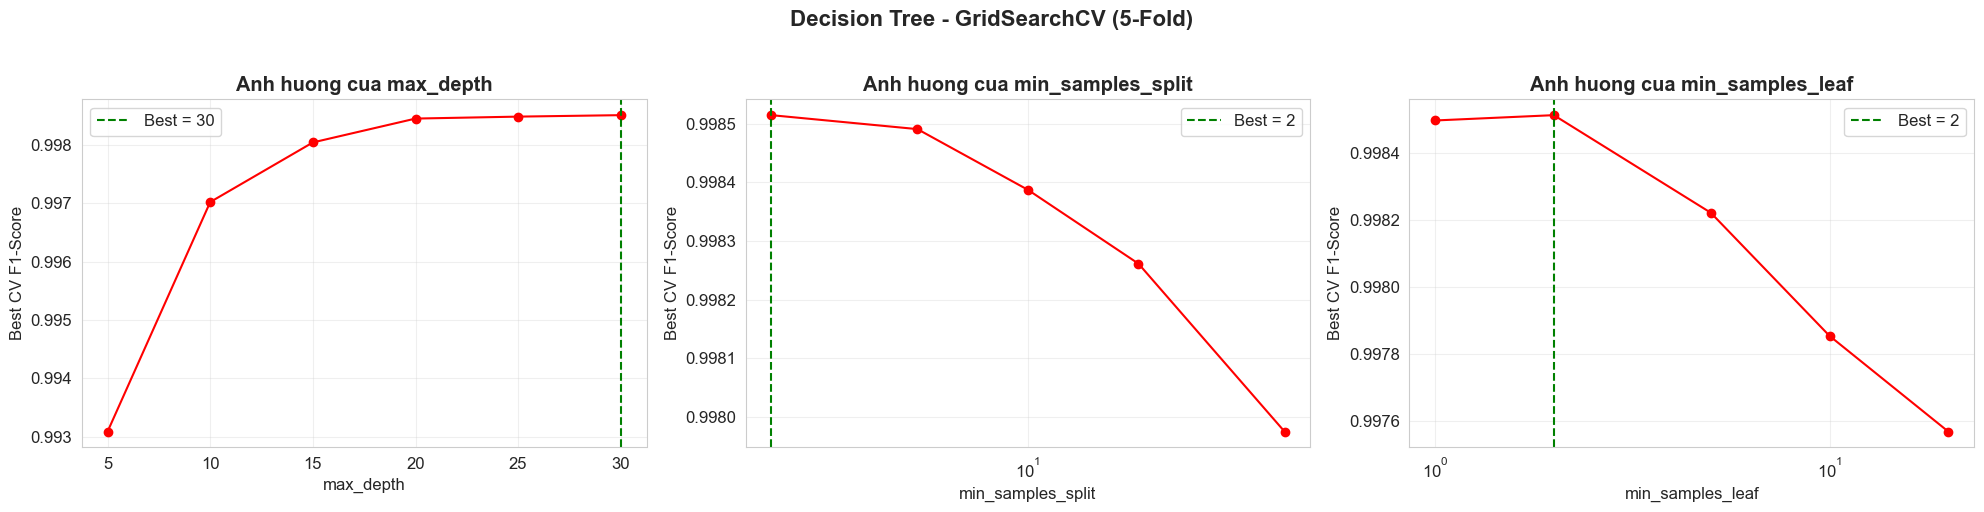

In [10]:
# === CELL 11: Tìm kiếm tham số tối ưu - Decision Tree (GridSearchCV) ===

from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
import time

print("=" * 60)
print("TIM KIEM THAM SO TOI UU - DECISION TREE (GridSearchCV)")
print("=" * 60)

# Định nghĩa lưới tham số
param_grid_dt = {
    'max_depth': [5, 10, 15, 20, 25, 30],
    'min_samples_split': [2, 5, 10, 20, 50],
    'min_samples_leaf': [1, 2, 5, 10, 20]
}

dt_base = DecisionTreeClassifier(
    class_weight='balanced',
    criterion='gini',
    random_state=42
)

print(f"Tong so to hop: {len(param_grid_dt['max_depth']) * len(param_grid_dt['min_samples_split']) * len(param_grid_dt['min_samples_leaf'])} to hop x 5-fold CV")

start_search = time.time()
grid_search_dt = GridSearchCV(
    estimator=dt_base,
    param_grid=param_grid_dt,
    cv=5,
    scoring='f1',
    n_jobs=4,
    verbose=1
)
grid_search_dt.fit(X_train_scaled, y_train)
search_time = time.time() - start_search

print(f"\nThoi gian tim kiem: {search_time:.2f} giay")
print(f"\nTham so toi uu:")
print(f"  max_depth = {grid_search_dt.best_params_['max_depth']}")
print(f"  min_samples_split = {grid_search_dt.best_params_['min_samples_split']}")
print(f"  min_samples_leaf = {grid_search_dt.best_params_['min_samples_leaf']}")
print(f"  Best CV F1-Score = {grid_search_dt.best_score_:.4f}")

# Lưu tham số tối ưu
best_depth = grid_search_dt.best_params_['max_depth']
best_split = grid_search_dt.best_params_['min_samples_split']
best_leaf = grid_search_dt.best_params_['min_samples_leaf']

# --- Trực quan hóa ảnh hưởng từng tham số ---
import pandas as pd
results = pd.DataFrame(grid_search_dt.cv_results_)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1. Ảnh hưởng max_depth
depth_scores = results.groupby('param_max_depth')['mean_test_score'].max()
axes[0].plot(depth_scores.index.astype(int), depth_scores.values, 'r-o', markersize=6)
axes[0].axvline(x=best_depth, color='green', linestyle='--', label=f'Best = {best_depth}')
axes[0].set_xlabel('max_depth')
axes[0].set_ylabel('Best CV F1-Score')
axes[0].set_title('Anh huong cua max_depth', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# 2. Ảnh hưởng min_samples_split
split_scores = results.groupby('param_min_samples_split')['mean_test_score'].max()
axes[1].plot(split_scores.index.astype(int), split_scores.values, 'r-o', markersize=6)
axes[1].axvline(x=best_split, color='green', linestyle='--', label=f'Best = {best_split}')
axes[1].set_xlabel('min_samples_split')
axes[1].set_ylabel('Best CV F1-Score')
axes[1].set_title('Anh huong cua min_samples_split', fontweight='bold')
axes[1].set_xscale('log')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# 3. Ảnh hưởng min_samples_leaf
leaf_scores = results.groupby('param_min_samples_leaf')['mean_test_score'].max()
axes[2].plot(leaf_scores.index.astype(int), leaf_scores.values, 'r-o', markersize=6)
axes[2].axvline(x=best_leaf, color='green', linestyle='--', label=f'Best = {best_leaf}')
axes[2].set_xlabel('min_samples_leaf')
axes[2].set_ylabel('Best CV F1-Score')
axes[2].set_title('Anh huong cua min_samples_leaf', fontweight='bold')
axes[2].set_xscale('log')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Decision Tree - GridSearchCV (5-Fold)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

KET QUA - DECISION TREE
Train Accuracy: 0.9991
Test Accuracy:  0.9973
Precision:      0.9987
Recall:         0.9983
F1-Score:       0.9985
AUC-ROC:        0.9934
Train Time:     0.6148s
Predict Time:   0.0033s

               precision    recall  f1-score   support

   Benign (0)       0.98      0.99      0.99      9687
Malicious (1)       1.00      1.00      1.00     89977

     accuracy                           1.00     99664
    macro avg       0.99      0.99      0.99     99664
 weighted avg       1.00      1.00      1.00     99664



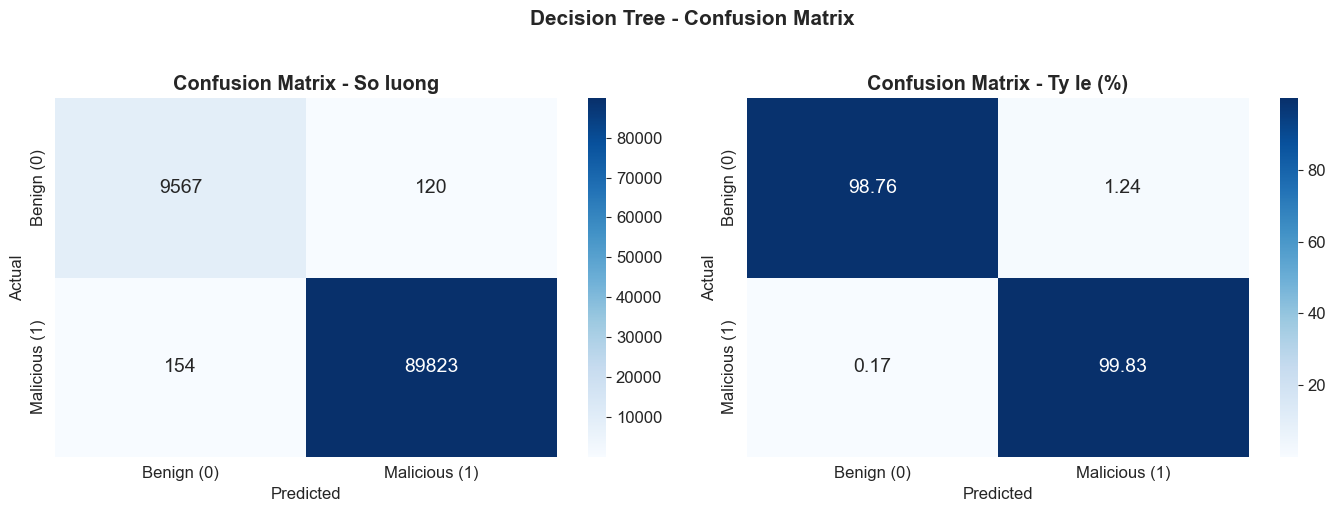

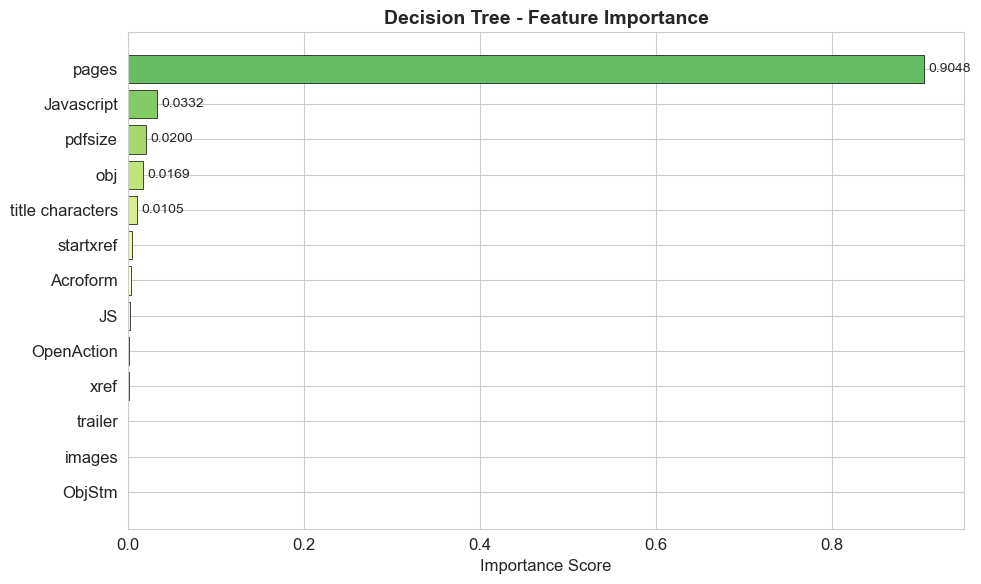

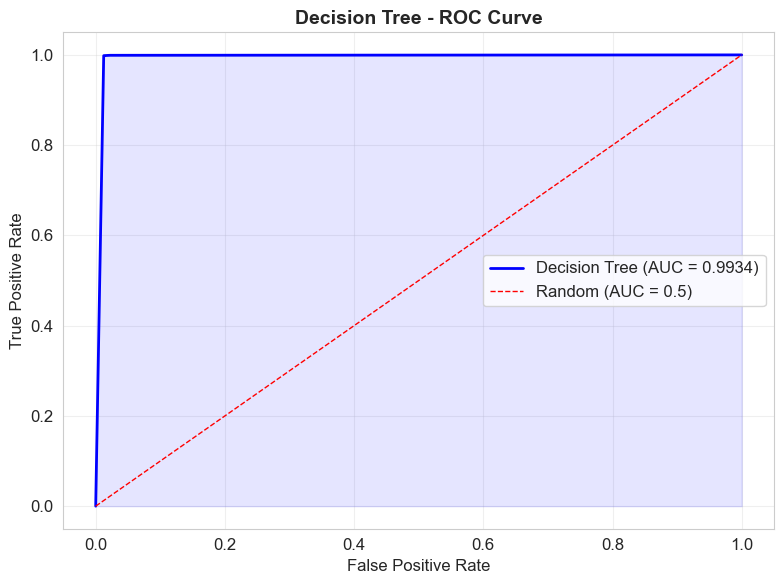

In [11]:
# === CELL 12: Huấn luyện và Đánh giá - Decision Tree ===

from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score, precision_score,
                             recall_score, roc_auc_score, roc_curve)
import time

# === HUAN LUYEN ===
dt_model = DecisionTreeClassifier(
    max_depth=best_depth,
    min_samples_split=best_split,
    min_samples_leaf=best_leaf,
    class_weight='balanced',
    criterion='gini',
    random_state=42
)

start_train = time.time()
dt_model.fit(X_train_scaled, y_train)
dt_train_time = time.time() - start_train

start_pred = time.time()
y_pred_dt = dt_model.predict(X_test_scaled)
dt_pred_time = time.time() - start_pred

y_pred_proba_dt = dt_model.predict_proba(X_test_scaled)[:, 1]

# === METRICS ===
dt_accuracy = accuracy_score(y_test, y_pred_dt)
dt_precision = precision_score(y_test, y_pred_dt)
dt_recall = recall_score(y_test, y_pred_dt)
dt_f1 = f1_score(y_test, y_pred_dt)
dt_auc = roc_auc_score(y_test, y_pred_proba_dt)

print("=" * 60)
print("KET QUA - DECISION TREE")
print("=" * 60)
print(f"Train Accuracy: {dt_model.score(X_train_scaled, y_train):.4f}")
print(f"Test Accuracy:  {dt_accuracy:.4f}")
print(f"Precision:      {dt_precision:.4f}")
print(f"Recall:         {dt_recall:.4f}")
print(f"F1-Score:       {dt_f1:.4f}")
print(f"AUC-ROC:        {dt_auc:.4f}")
print(f"Train Time:     {dt_train_time:.4f}s")
print(f"Predict Time:   {dt_pred_time:.4f}s")

print(f"\n{classification_report(y_test, y_pred_dt, target_names=['Benign (0)', 'Malicious (1)'])}")

# === CONFUSION MATRIX ===
cm_dt = confusion_matrix(y_test, y_pred_dt)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Benign (0)', 'Malicious (1)'],
            yticklabels=['Benign (0)', 'Malicious (1)'],
            ax=axes[0], annot_kws={'size': 14})
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix - So luong', fontweight='bold')

cm_dt_pct = cm_dt.astype('float') / cm_dt.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_dt_pct, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=['Benign (0)', 'Malicious (1)'],
            yticklabels=['Benign (0)', 'Malicious (1)'],
            ax=axes[1], annot_kws={'size': 14})
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title('Confusion Matrix - Ty le (%)', fontweight='bold')

plt.suptitle('Decision Tree - Confusion Matrix', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# === FEATURE IMPORTANCE ===
feature_importance = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Importance': dt_model.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.RdYlGn(np.linspace(0.2, 0.8, len(feature_importance)))
ax.barh(feature_importance['Feature'], feature_importance['Importance'],
        color=colors, edgecolor='black', linewidth=0.5)
ax.set_xlabel('Importance Score')
ax.set_title('Decision Tree - Feature Importance', fontsize=14, fontweight='bold')
for bar, val in zip(ax.patches, feature_importance['Importance']):
    if val > 0.01:
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

# === ROC CURVE ===
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_pred_proba_dt)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_dt, tpr_dt, 'b-', linewidth=2, label=f'Decision Tree (AUC = {dt_auc:.4f})')
ax.plot([0, 1], [0, 1], 'r--', linewidth=1, label='Random (AUC = 0.5)')
ax.fill_between(fpr_dt, tpr_dt, alpha=0.1, color='blue')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Decision Tree - ROC Curve', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

TIM KIEM THAM SO TOI UU - RANDOM FOREST (RandomizedSearchCV)
Fitting 5 folds for each of 30 candidates, totalling 150 fits

Thoi gian tim kiem: 263.30 giay

Tham so toi uu:
  n_estimators = 300
  min_samples_split = 5
  max_features = sqrt
  max_depth = None
  Best CV F1-Score = 0.9991


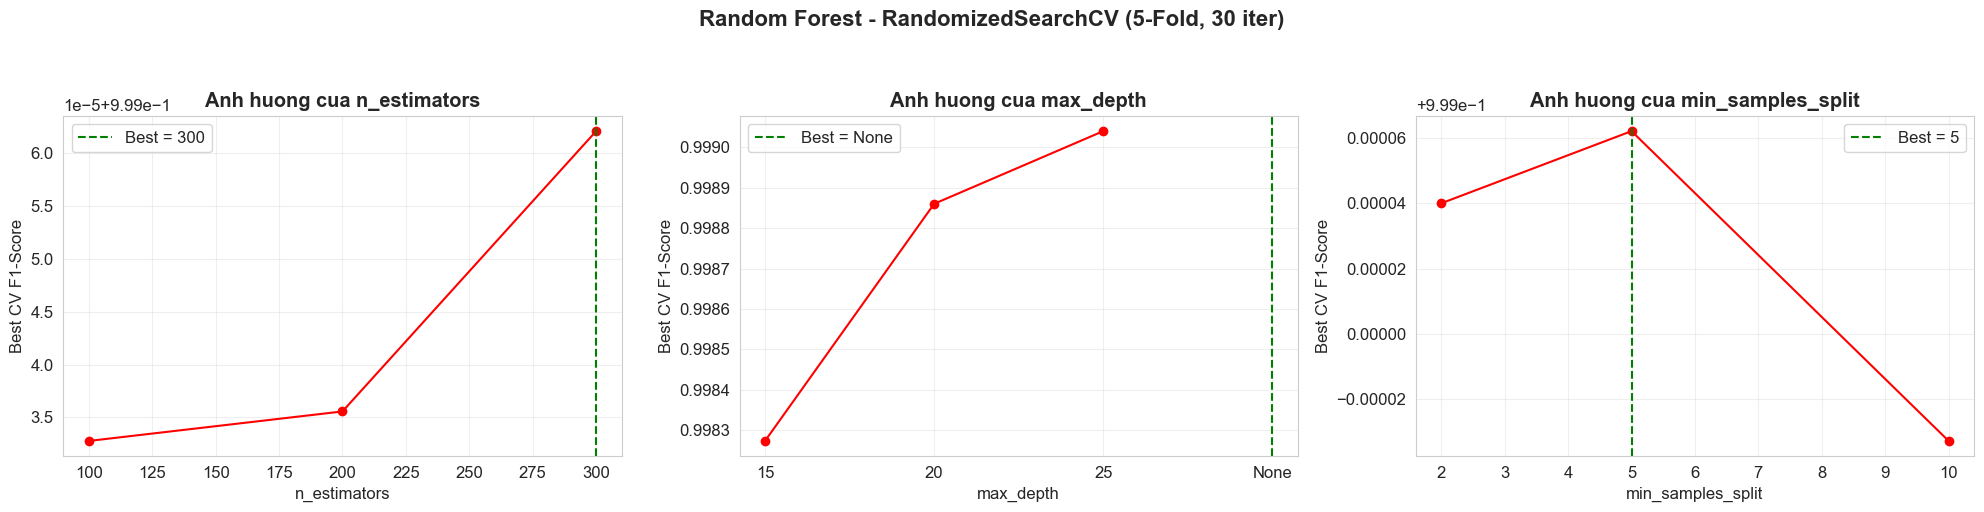

In [12]:
# === CELL 13: Tìm kiếm tham số tối ưu - Random Forest (RandomizedSearchCV) ===

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RandomizedSearchCV
import time

print("=" * 60)
print("TIM KIEM THAM SO TOI UU - RANDOM FOREST (RandomizedSearchCV)")
print("=" * 60)

param_dist_rf = {
    'n_estimators': [100, 200, 300],
    'max_depth': [15, 20, 25, None],
    'min_samples_split': [2, 5, 10],
    'max_features': ['sqrt', 'log2']
}

rf_base = RandomForestClassifier(
    class_weight='balanced',
    oob_score=True,
    random_state=42,
    n_jobs=4
)

start_search = time.time()
random_search_rf = RandomizedSearchCV(
    estimator=rf_base,
    param_distributions=param_dist_rf,
    n_iter=30,
    cv=5,
    scoring='f1',
    n_jobs=4,
    random_state=42,
    verbose=1
)
random_search_rf.fit(X_train_scaled, y_train)
search_time = time.time() - start_search

print(f"\nThoi gian tim kiem: {search_time:.2f} giay")
print(f"\nTham so toi uu:")
for param, val in random_search_rf.best_params_.items():
    print(f"  {param} = {val}")
print(f"  Best CV F1-Score = {random_search_rf.best_score_:.4f}")

best_n_est = random_search_rf.best_params_['n_estimators']
best_depth_rf = random_search_rf.best_params_['max_depth']
best_split_rf = random_search_rf.best_params_['min_samples_split']
best_feat = random_search_rf.best_params_['max_features']

# --- Trực quan hóa ---
results_rf = pd.DataFrame(random_search_rf.cv_results_)

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

est_scores = results_rf.groupby('param_n_estimators')['mean_test_score'].max()
axes[0].plot(est_scores.index.astype(int), est_scores.values, 'r-o', markersize=6)
axes[0].axvline(x=best_n_est, color='green', linestyle='--', label=f'Best = {best_n_est}')
axes[0].set_xlabel('n_estimators')
axes[0].set_ylabel('Best CV F1-Score')
axes[0].set_title('Anh huong cua n_estimators', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

depth_scores_rf = results_rf.groupby('param_max_depth')['mean_test_score'].max()
depth_labels = [str(d) for d in depth_scores_rf.index]
axes[1].plot(depth_labels, depth_scores_rf.values, 'r-o', markersize=6)
axes[1].axvline(x=str(best_depth_rf), color='green', linestyle='--', label=f'Best = {best_depth_rf}')
axes[1].set_xlabel('max_depth')
axes[1].set_ylabel('Best CV F1-Score')
axes[1].set_title('Anh huong cua max_depth', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

split_scores_rf = results_rf.groupby('param_min_samples_split')['mean_test_score'].max()
axes[2].plot(split_scores_rf.index.astype(int), split_scores_rf.values, 'r-o', markersize=6)
axes[2].axvline(x=best_split_rf, color='green', linestyle='--', label=f'Best = {best_split_rf}')
axes[2].set_xlabel('min_samples_split')
axes[2].set_ylabel('Best CV F1-Score')
axes[2].set_title('Anh huong cua min_samples_split', fontweight='bold')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.suptitle('Random Forest - RandomizedSearchCV (5-Fold, 30 iter)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

KET QUA - RANDOM FOREST
Train Accuracy: 0.9994
Test Accuracy:  0.9981
OOB Score:      0.9983
Precision:      0.9991
Recall:         0.9988
F1-Score:       0.9990
AUC-ROC:        1.0000
Train Time:     5.8622s
Predict Time:   0.0758s

               precision    recall  f1-score   support

   Benign (0)       0.99      0.99      0.99      9687
Malicious (1)       1.00      1.00      1.00     89977

     accuracy                           1.00     99664
    macro avg       0.99      1.00      0.99     99664
 weighted avg       1.00      1.00      1.00     99664



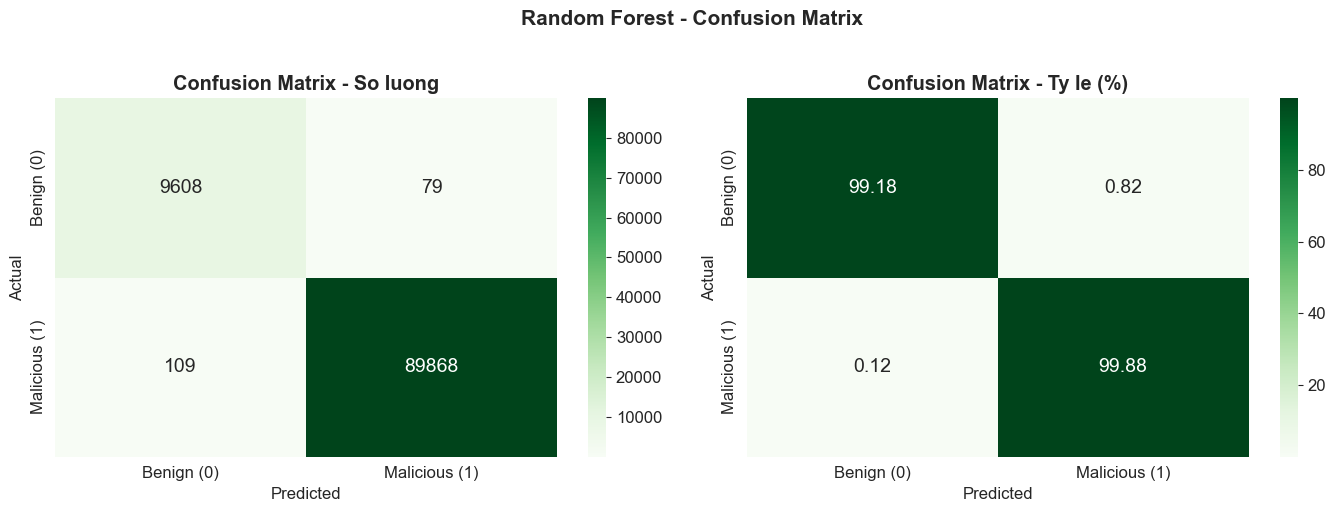

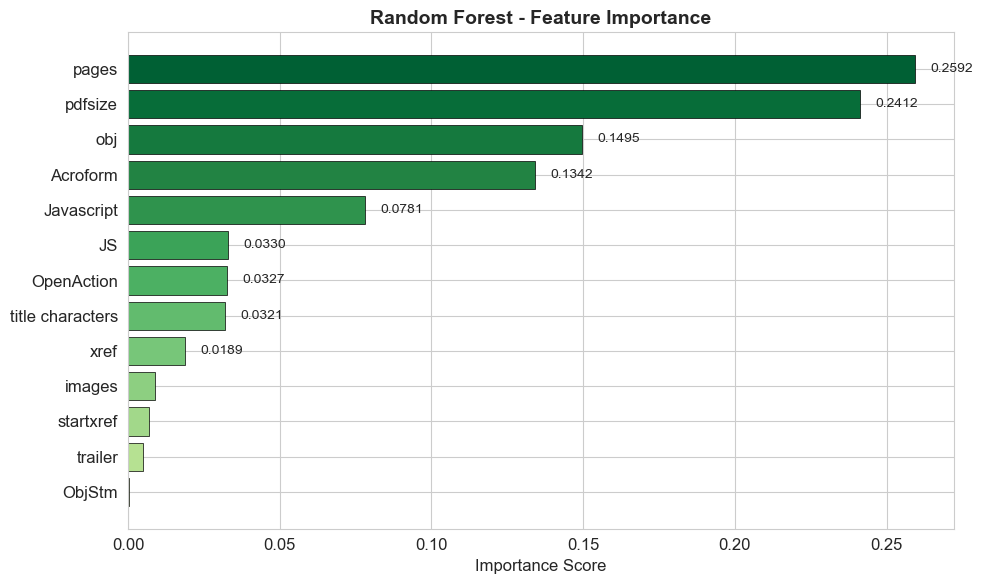

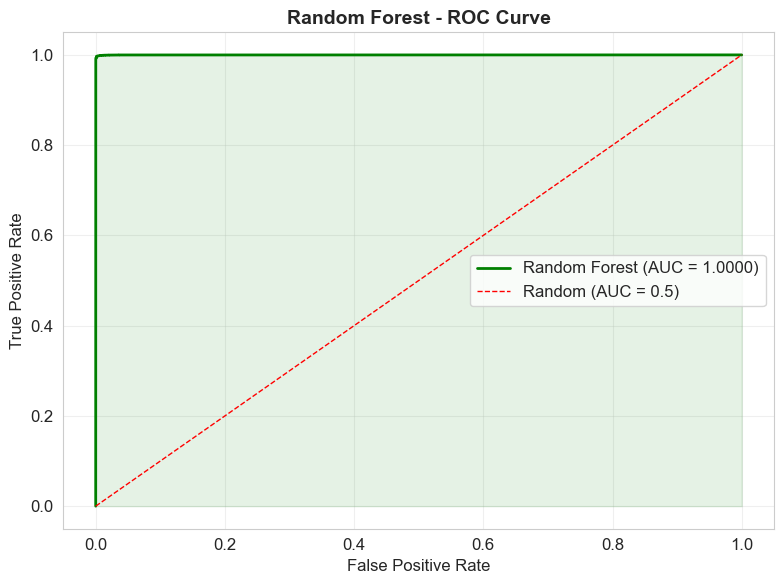

In [17]:
# === CELL 14: Huấn luyện và Đánh giá - Random Forest ===

from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score, precision_score,
                             recall_score, roc_auc_score, roc_curve)
import time

# === HUAN LUYEN ===
rf_model = RandomForestClassifier(
    n_estimators=best_n_est,
    max_depth=best_depth_rf,
    min_samples_split=best_split_rf,
    max_features=best_feat,
    class_weight='balanced',
    oob_score=True,
    random_state=42,
    n_jobs=-1
)

start_train = time.time()
rf_model.fit(X_train_scaled, y_train)
rf_train_time = time.time() - start_train

start_pred = time.time()
y_pred_rf = rf_model.predict(X_test_scaled)
rf_pred_time = time.time() - start_pred

y_pred_proba_rf = rf_model.predict_proba(X_test_scaled)[:, 1]

# === METRICS ===
rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_precision = precision_score(y_test, y_pred_rf)
rf_recall = recall_score(y_test, y_pred_rf)
rf_f1 = f1_score(y_test, y_pred_rf)
rf_auc = roc_auc_score(y_test, y_pred_proba_rf)

print("=" * 60)
print("KET QUA - RANDOM FOREST")
print("=" * 60)
print(f"Train Accuracy: {rf_model.score(X_train_scaled, y_train):.4f}")
print(f"Test Accuracy:  {rf_accuracy:.4f}")
print(f"OOB Score:      {rf_model.oob_score_:.4f}")
print(f"Precision:      {rf_precision:.4f}")
print(f"Recall:         {rf_recall:.4f}")
print(f"F1-Score:       {rf_f1:.4f}")
print(f"AUC-ROC:        {rf_auc:.4f}")
print(f"Train Time:     {rf_train_time:.4f}s")
print(f"Predict Time:   {rf_pred_time:.4f}s")

print(f"\n{classification_report(y_test, y_pred_rf, target_names=['Benign (0)', 'Malicious (1)'])}")

# === CONFUSION MATRIX ===
cm_rf = confusion_matrix(y_test, y_pred_rf)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Benign (0)', 'Malicious (1)'],
            yticklabels=['Benign (0)', 'Malicious (1)'],
            ax=axes[0], annot_kws={'size': 14})
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')
axes[0].set_title('Confusion Matrix - So luong', fontweight='bold')

cm_rf_pct = cm_rf.astype('float') / cm_rf.sum(axis=1)[:, np.newaxis] * 100
sns.heatmap(cm_rf_pct, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=['Benign (0)', 'Malicious (1)'],
            yticklabels=['Benign (0)', 'Malicious (1)'],
            ax=axes[1], annot_kws={'size': 14})
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
axes[1].set_title('Confusion Matrix - Ty le (%)', fontweight='bold')

plt.suptitle('Random Forest - Confusion Matrix', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# === FEATURE IMPORTANCE ===
feature_importance_rf = pd.DataFrame({
    'Feature': X_train_scaled.columns,
    'Importance': rf_model.feature_importances_
}).sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.YlGn(np.linspace(0.3, 0.9, len(feature_importance_rf)))
ax.barh(feature_importance_rf['Feature'], feature_importance_rf['Importance'],
        color=colors, edgecolor='black', linewidth=0.5)
ax.set_xlabel('Importance Score')
ax.set_title('Random Forest - Feature Importance', fontsize=14, fontweight='bold')
for bar, val in zip(ax.patches, feature_importance_rf['Importance']):
    if val > 0.01:
        ax.text(val + 0.005, bar.get_y() + bar.get_height()/2,
                f'{val:.4f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

# === ROC CURVE ===
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_pred_proba_rf)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr_rf, tpr_rf, 'g-', linewidth=2, label=f'Random Forest (AUC = {rf_auc:.4f})')
ax.plot([0, 1], [0, 1], 'r--', linewidth=1, label='Random (AUC = 0.5)')
ax.fill_between(fpr_rf, tpr_rf, alpha=0.1, color='green')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('Random Forest - ROC Curve', fontsize=14, fontweight='bold')
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Extreme Gradient Boosting (XGBoost)

In [ ]:
# === CELL 1: Tìm kiếm tham số tối ưu - XGBoost ===

from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
import time

print("=" * 60)
print("TIM KIEM THAM SO TOI UU - XGBOOST")
print("=" * 60)

# Tính scale_pos_weight
n_benign = (y_train == 0).sum()
n_malware = (y_train == 1).sum()
scale_pos_weight_value = n_benign / n_malware

# Không gian tham số
param_dist_xgb = {
    'n_estimators': [100, 200, 300],
    'max_depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

xgb_base = XGBClassifier(
    tree_method='hist',
    scale_pos_weight=scale_pos_weight_value,
    random_state=42,
    n_jobs=1,   # chừa 1 nhân để CPU xử lý các tác vụ khác của máy tính
    verbosity=0,
    use_label_encoder=False
)

random_search_xgb = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist_xgb,
    n_iter=20,
    cv=5,
    scoring='f1',
    n_jobs=-1,  # giữ nguyên
    verbose=1,
    random_state=42
)
random_search_xgb.fit(X_train_scaled, y_train)

search_time = time.time() - start_search

print(f"\nThoi gian tim kiem: {search_time:.2f} giay")
print("\nTham so toi uu:")
for param, val in random_search_xgb.best_params_.items():
    print(f"  {param}: {val}")

print(f"Best CV F1-Score: {random_search_xgb.best_score_:.4f}")

TIM KIEM THAM SO TOI UU - XGBOOST
Fitting 5 folds for each of 20 candidates, totalling 100 fits

Thoi gian tim kiem: 500.02 giay

Tham so toi uu:
  subsample: 0.9
  n_estimators: 300
  max_depth: 8
  learning_rate: 0.1
  colsample_bytree: 0.8
Best CV F1-Score: 0.9988


HUAN LUYEN VA DANH GIA - XGBOOST
Train Accuracy: 0.9983
Test Accuracy:  0.9977
Precision:      0.9996
Recall:         0.9978
F1-Score:       0.9987
AUC-ROC:        1.0000
Train Time:     3.4013s
Predict Time:   0.2058s

Classification Report:
               precision    recall  f1-score   support

   Benign (0)       0.98      1.00      0.99      9687
Malicious (1)       1.00      1.00      1.00     89977

     accuracy                           1.00     99664
    macro avg       0.99      1.00      0.99     99664
 weighted avg       1.00      1.00      1.00     99664



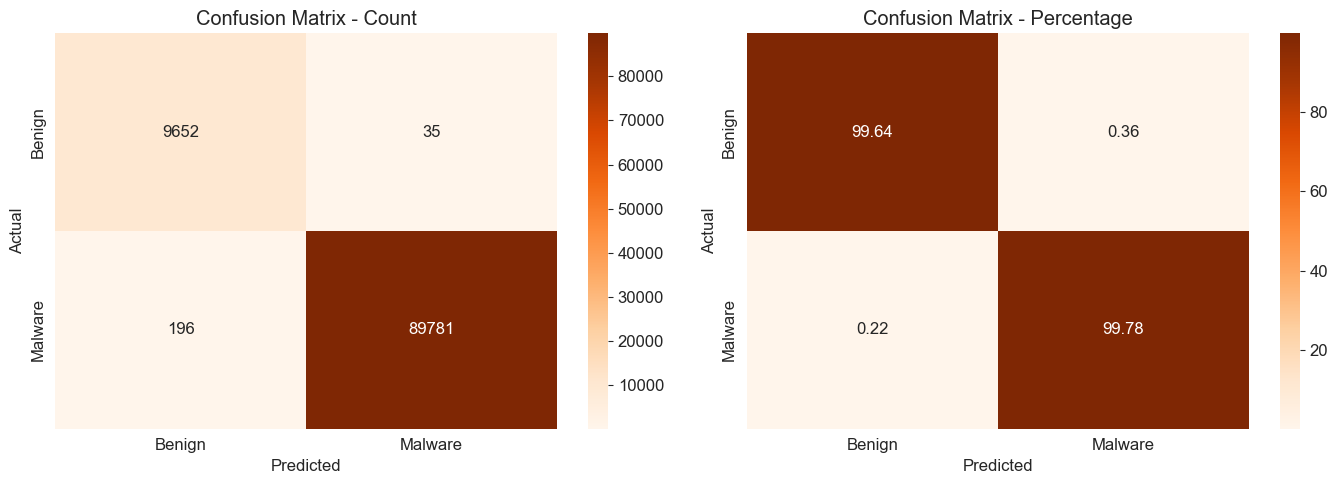

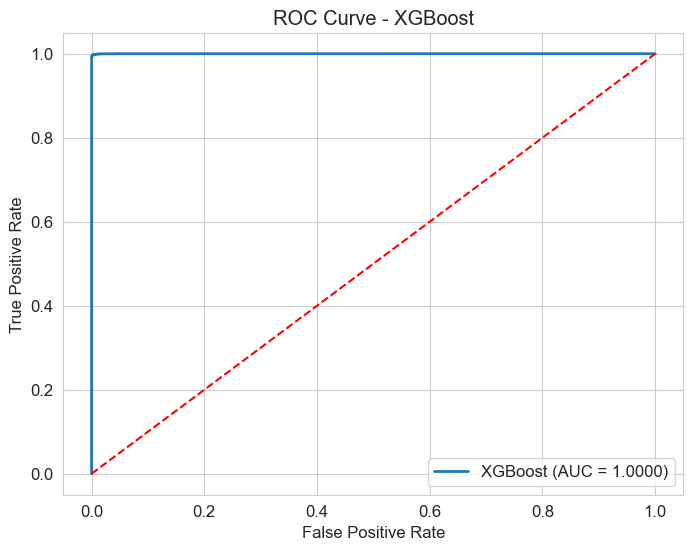

In [ ]:
# === Huấn luyện và Đánh giá - XGBoost (optimized resource, same output) ===

from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score, precision_score,
                             recall_score, roc_auc_score, roc_curve)
import seaborn as sns
import matplotlib.pyplot as plt
import time
import gc

gc.collect()

print("=" * 60)
print("HUAN LUYEN VA DANH GIA - XGBOOST")
print("=" * 60)

# Lấy model tốt nhất
best_xgb = random_search_xgb.best_estimator_

# Quan trọng: giới hạn XGBoost dùng 1 core để tránh oversubscription
best_xgb.set_params(n_jobs=1)

# Train
start_train = time.time()
best_xgb.fit(X_train_scaled, y_train)
xgb_train_time = time.time() - start_train

# Predict
start_pred = time.time()
y_pred_xgb = best_xgb.predict(X_test_scaled)
xgb_pred_time = time.time() - start_pred

y_pred_proba_xgb = best_xgb.predict_proba(X_test_scaled)[:, 1]

# Metrics
xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_precision = precision_score(y_test, y_pred_xgb)
xgb_recall = recall_score(y_test, y_pred_xgb)
xgb_f1 = f1_score(y_test, y_pred_xgb)
xgb_auc = roc_auc_score(y_test, y_pred_proba_xgb)

print(f"Train Accuracy: {best_xgb.score(X_train_scaled, y_train):.4f}")
print(f"Test Accuracy:  {xgb_accuracy:.4f}")
print(f"Precision:      {xgb_precision:.4f}")
print(f"Recall:         {xgb_recall:.4f}")
print(f"F1-Score:       {xgb_f1:.4f}")
print(f"AUC-ROC:        {xgb_auc:.4f}")
print(f"Train Time:     {xgb_train_time:.4f}s")
print(f"Predict Time:   {xgb_pred_time:.4f}s")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb,
      target_names=['Benign (0)', 'Malicious (1)']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_xgb)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Benign', 'Malware'],
            yticklabels=['Benign', 'Malware'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix - Count')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

sns.heatmap(cm_pct, annot=True, fmt='.2f', cmap='Oranges',
            xticklabels=['Benign', 'Malware'],
            yticklabels=['Benign', 'Malware'],
            ax=axes[1])
axes[1].set_title('Confusion Matrix - Percentage')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_xgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f'XGBoost (AUC = {xgb_auc:.4f})')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - XGBoost')
plt.legend()
plt.grid(True)
plt.show()

# Tối ưu tham số (LightGBM)

In [24]:
# === Tìm kiếm tham số tối ưu - LightGBM ===

from lightgbm import LGBMClassifier
from sklearn.model_selection import RandomizedSearchCV
import time

print("=" * 60)
print("TIM KIEM THAM SO TOI UU - LIGHTGBM")
print("=" * 60)

# Không gian tham số
param_dist_lgb = {
    'n_estimators': [100, 200, 300],
    'num_leaves': [31, 63, 127],
    'learning_rate': [0.01, 0.05, 0.1],
    'subsample': [0.7, 0.8, 0.9],
    'colsample_bytree': [0.7, 0.8, 0.9]
}

# Model base
lgb_base = LGBMClassifier(
    is_unbalance=True,   # xử lý imbalance
    random_state=42,
    n_jobs=1             # tránh oversubscription
)

start_search = time.time()

random_search_lgb = RandomizedSearchCV(
    estimator=lgb_base,
    param_distributions=param_dist_lgb,
    n_iter=20,
    cv=5,
    scoring='f1',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search_lgb.fit(X_train_scaled, y_train)

search_time = time.time() - start_search

print(f"\nThoi gian tim kiem: {search_time:.2f} giay")
print("\nTham so toi uu:")
for param, val in random_search_lgb.best_params_.items():
    print(f"  {param}: {val}")

print(f"Best CV F1-Score: {random_search_lgb.best_score_:.4f}")

TIM KIEM THAM SO TOI UU - LIGHTGBM
Fitting 5 folds for each of 20 candidates, totalling 100 fits
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 287926, number of negative: 30997
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 287926, number of negative: 30997
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 287926, number of negative: 30997
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 287927, number of negative: 30996
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 287926, number of negative: 30997
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 287927, number of negativ

HUAN LUYEN VA DANH GIA - LIGHTGBM
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 359908, number of negative: 38746
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.014144 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 743
[LightGBM] [Info] Number of data points in the train set: 398654, number of used features: 13
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.902808 -> initscore=2.228821
[LightGBM] [Info] Start training from score 2.228821
Train Accuracy: 0.9998
Test Accuracy:  0.9978
Precision:      0.9991
Recall:         0.9985
F1-Score:       0.9988
AUC-ROC:        1.0000
Train Time:     2.0747s
Predict Time:   0.6058s

Classification Report:
               precision    recall  f1-score   support

   Benign (0)       0.99      0.99      0.99      9687
Maliciou

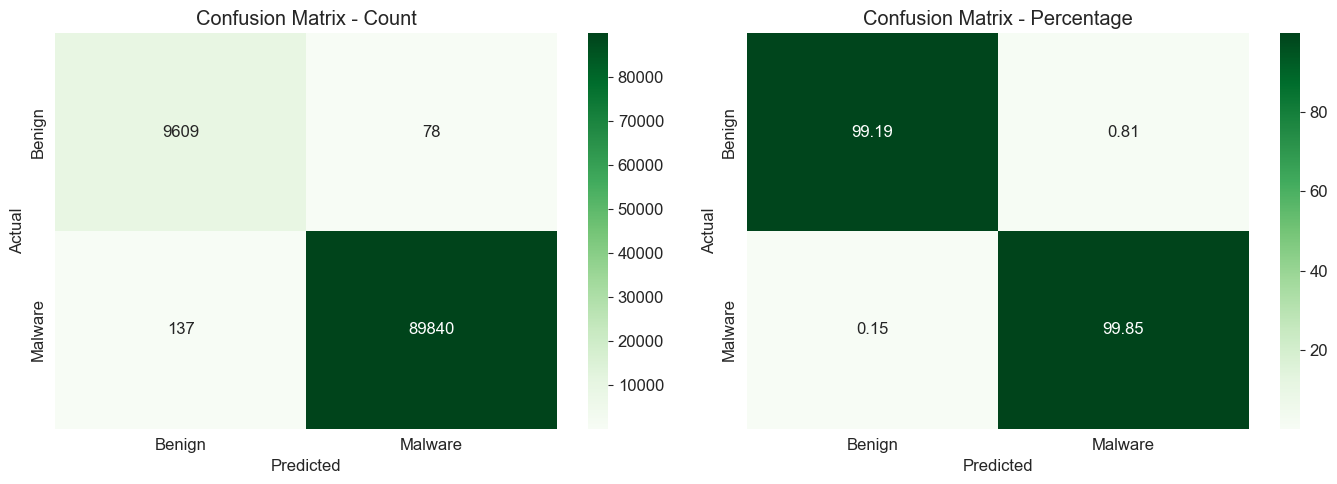

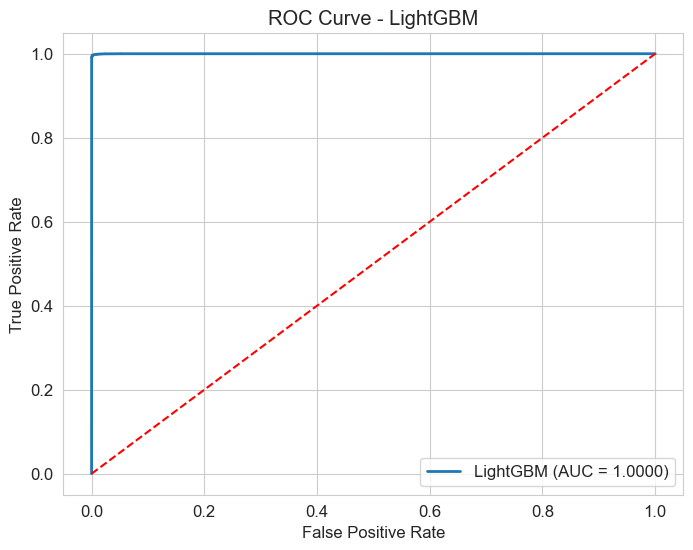

In [25]:
# === Huấn luyện và Đánh giá - LightGBM ===

from sklearn.metrics import (classification_report, confusion_matrix,
                             accuracy_score, f1_score, precision_score,
                             recall_score, roc_auc_score, roc_curve)
import seaborn as sns
import matplotlib.pyplot as plt
import time
import gc

gc.collect()

print("=" * 60)
print("HUAN LUYEN VA DANH GIA - LIGHTGBM")
print("=" * 60)

# Lấy model tốt nhất
best_lgb = random_search_lgb.best_estimator_

# Train
start_train = time.time()
best_lgb.fit(X_train_scaled, y_train)
lgb_train_time = time.time() - start_train

# Predict
start_pred = time.time()
y_pred_lgb = best_lgb.predict(X_test_scaled)
lgb_pred_time = time.time() - start_pred

y_pred_proba_lgb = best_lgb.predict_proba(X_test_scaled)[:, 1]

# Metrics
lgb_accuracy = accuracy_score(y_test, y_pred_lgb)
lgb_precision = precision_score(y_test, y_pred_lgb)
lgb_recall = recall_score(y_test, y_pred_lgb)
lgb_f1 = f1_score(y_test, y_pred_lgb)
lgb_auc = roc_auc_score(y_test, y_pred_proba_lgb)

print(f"Train Accuracy: {best_lgb.score(X_train_scaled, y_train):.4f}")
print(f"Test Accuracy:  {lgb_accuracy:.4f}")
print(f"Precision:      {lgb_precision:.4f}")
print(f"Recall:         {lgb_recall:.4f}")
print(f"F1-Score:       {lgb_f1:.4f}")
print(f"AUC-ROC:        {lgb_auc:.4f}")
print(f"Train Time:     {lgb_train_time:.4f}s")
print(f"Predict Time:   {lgb_pred_time:.4f}s")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_lgb,
      target_names=['Benign (0)', 'Malicious (1)']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_lgb)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Benign', 'Malware'],
            yticklabels=['Benign', 'Malware'],
            ax=axes[0])
axes[0].set_title('Confusion Matrix - Count')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

sns.heatmap(cm_pct, annot=True, fmt='.2f', cmap='Greens',
            xticklabels=['Benign', 'Malware'],
            yticklabels=['Benign', 'Malware'],
            ax=axes[1])
axes[1].set_title('Confusion Matrix - Percentage')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.tight_layout()
plt.show()

# ROC Curve
fpr, tpr, _ = roc_curve(y_test, y_pred_proba_lgb)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f'LightGBM (AUC = {lgb_auc:.4f})')
plt.plot([0, 1], [0, 1], 'r--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - LightGBM')
plt.legend()
plt.grid(True)
plt.show()